# 1D CNN — Human Activity Recognition
**CS3244 Group 32 | Elysia Selena Alston & Lu Ji Yuan**

Dataset: Smartphone-Based Recognition of Human Activities and Postural Transitions (UCI)

Each row in X_train/X_test is already a pre-extracted 561-feature vector from a 128-sample,
2.56s window. We treat each row as a (561, 1) signal so Conv1D can learn feature interactions.

## 1. Imports

In [ ]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, jaccard_score,
    roc_auc_score, roc_curve, auc
)

random.seed(3244)
np.random.seed(3244)
tf.random.set_seed(3244)


## 2. Load data

Each row = one 128-sample window already pre-processed into 561 features.
Labels are integers 1–12 mapping to 12 activity classes.

In [2]:
X_train = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/Train/X_train.txt', sep=r'\s+', header=None).values
y_train = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/Train/Y_train.txt', sep=r'\s+', header=None).values.ravel()
X_test  = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/Test/X_test.txt',  sep=r'\s+', header=None).values
y_test  = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/Test/Y_test.txt',  sep=r'\s+', header=None).values.ravel()

labels_df        = pd.read_csv('smartphone+based+recognition+of+human+activities+and+postural+transitions/activity_labels.txt', sep=r'\s+', header=None)
activity_mapping = dict(zip(labels_df[0], labels_df[1]))
label_names      = [activity_mapping[i] for i in sorted(activity_mapping)]

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print(f'Classes: {label_names}')

X_train: (7767, 561) | y_train: (7767,)
X_test:  (3162, 561)  | y_test:  (3162,)
Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING', 'STAND_TO_SIT', 'SIT_TO_STAND', 'SIT_TO_LIE', 'LIE_TO_SIT', 'STAND_TO_LIE', 'LIE_TO_STAND']


## 3. Prepare tensors

our labels were from 1-12 but Keras expects 0-11, so we just minus 1
also,  Keras Conv1D needs a 3D input, so we add an extra dimension at the end. 
hence, each sample has 561 features, and 1 channel

In [3]:
# Labels are 1-indexed (1-12), shift to 0-indexed (0-11)
y_train_0 = y_train - 1
y_test_0  = y_test  - 1
n_classes  = len(activity_mapping)

# Keras Conv1D expects shape (samples, length, channels)
# We reshape from (7767, 561) → (7767, 561, 1)
X_train_k = X_train.reshape(-1, 561, 1)
X_test_k  = X_test.reshape(-1, 561, 1)

print(f'X_train shape: {X_train_k.shape}')
print(f'X_test shape:  {X_test_k.shape}')
print(f'Number of classes: {n_classes}')

X_train shape: (7767, 561, 1)
X_test shape:  (3162, 561, 1)
Number of classes: 12


## 4. DataLoaders with train/val split

In [4]:
model = Sequential([
    Input(shape=(561, 1)),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 561, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 561, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 561, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 561, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,764 (135.80 KB)

 Trainable params: 34,380 (134.30 KB)

 Non-trainable params: 384 (1.50 KB)

33,764 parameters -> quite small and lightweight, means the model is simple and fast to train.

## 5. Model definition & Training


In [5]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,             
    restore_best_weights=True
)

history = model.fit(
    X_train_k, y_train_0,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.4207 - loss: 1.3366 - val_accuracy: 0.2136 - val_loss: 1.9900
Epoch 2/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.5348 - loss: 1.0647 - val_accuracy: 0.3205 - val_loss: 2.3511
Epoch 3/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.6381 - loss: 0.8616 - val_accuracy: 0.3205 - val_loss: 2.9197
Epoch 4/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.6887 - loss: 0.7364 - val_accuracy: 0.3205 - val_loss: 3.4477
Epoch 5/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.7269 - loss: 0.6434 - val_accuracy: 0.3205 - val_loss: 3.5707
Epoch 6/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.7597 - loss: 0.5833 - val_accuracy: 0.4350 - val_loss: 2.2842
Epoch 7/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.7878 - loss: 0.5318 - val_accuracy: 0.4826 - val_loss: 1.1970
Epoch 8/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.8333 - loss: 0.4636 

## 6. Training curves

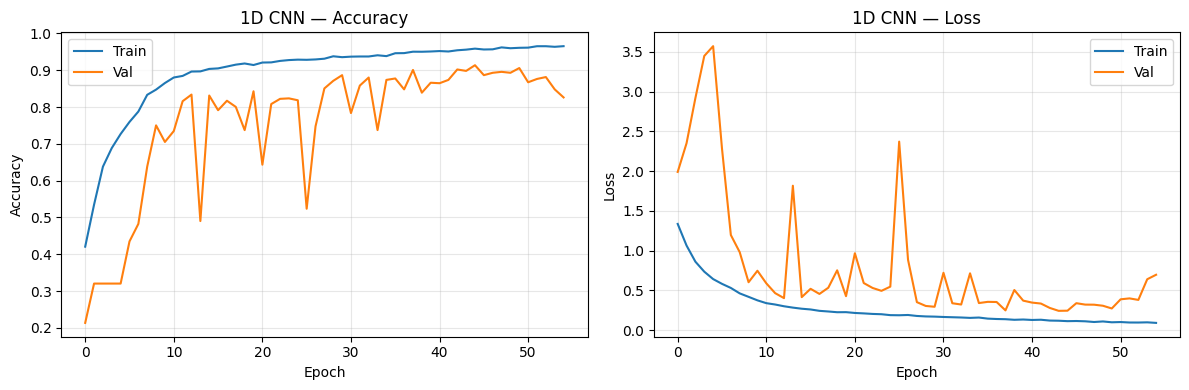

In [6]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('1D CNN — Accuracy')
plt.legend()
plt.grid(alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('1D CNN — Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_cnn1d.png', dpi=150)
plt.show()

Accuracy plot:
Train accuracy climbs steadily and peaks around 96%.
Val accuracy is very noisy with large dips at epochs ~13, 20, and 25, but generally 
recovers and stays around 83-90%. The gap between train and val is moderate, suggesting mild 
overfitting, but Dropout and BatchNormalization are keeping it in check.

Loss plot:
The spike in val loss at epochs 1-3 is expected because BatchNormalization takes a few epochs 
to stabilise its running statistics. The repeated spikes in val loss throughout training 
(epochs 13, 20, 25) correspond to the dips in val accuracy (due to the small 
validation set size (10% of ~7,700 samples)). Train loss decreases smoothly and consistently throughout.

## 8. Test set evaluation

In [7]:
y_pred_probs = model.predict(X_test_k)
y_pred       = np.argmax(y_pred_probs, axis=1)

pred_names = [activity_mapping[p + 1] for p in y_pred]
true_names = [activity_mapping[t + 1] for t in y_test_0]

print('=== Test Set Results ===')
print(f'Accuracy     : {accuracy_score(true_names, pred_names):.4f}')
print(f'F1 (macro)   : {f1_score(true_names, pred_names, average="macro"):.4f}')
print(f'F1 (weighted): {f1_score(true_names, pred_names, average="weighted"):.4f}')
print()
print(classification_report(
    true_names,
    pred_names,
    target_names=label_names,
    zero_division=0
))

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
=== Test Set Results ===
Accuracy     : 0.8403
F1 (macro)   : 0.6707
F1 (weighted): 0.8337

                    precision    recall  f1-score   support

           WALKING       0.90      1.00      0.95       545
  WALKING_UPSTAIRS       0.31      0.16      0.21        25
WALKING_DOWNSTAIRS       0.44      0.70      0.54        27
           SITTING       0.97      0.58      0.73       508
          STANDING       0.50      0.28      0.36        32
            LAYING       0.71      0.50      0.59        10
      STAND_TO_SIT       0.76      0.96      0.85       556
      SIT_TO_STAND       0.59      0.61      0.60        49
        SIT_TO_LIE       0.67      0.61      0.64        23
        LIE_TO_SIT       0.86      0.90      0.88       496
      STAND_TO_LIE       0.89      0.81      0.85       420
      LIE_TO_STAND       0.85      0.89      0.87       471

          accuracy                           0.84      3162
         macro avg       0.

Overall: 84% accuracy, 0.67 macro F1

Classes doing well:
- WALKING: 95% F1 
- STAND_TO_SIT: 85% F1 
- LIE_TO_SIT: 88% F1 
- STAND_TO_LIE: 85% F1, LIE_TO_STAND: 87% F1 

Classes doing poorly:
- WALKING_UPSTAIRS: 21% F1 (frequently confused with WALKING, only 25 test samples)
- STANDING: 36% F1 (confused with SITTING, both are quasi-static postures with similar sensor signatures, only 32 test samples)
- WALKING_DOWNSTAIRS: 54% F1 (only 27 test samples)

Looking at the support column, the poorly performing classes all have very small test sets 
(10, 25, 27, 32 samples). with so few examples, the model barely encountered these classes during training. 
The macro F1 (0.67) being noticeably lower than weighted F1 (0.84) confirms that the model 
performs well on frequent classes but struggles on rare ones, which macro F1 penalises equally.

## 9. Confusion matrix

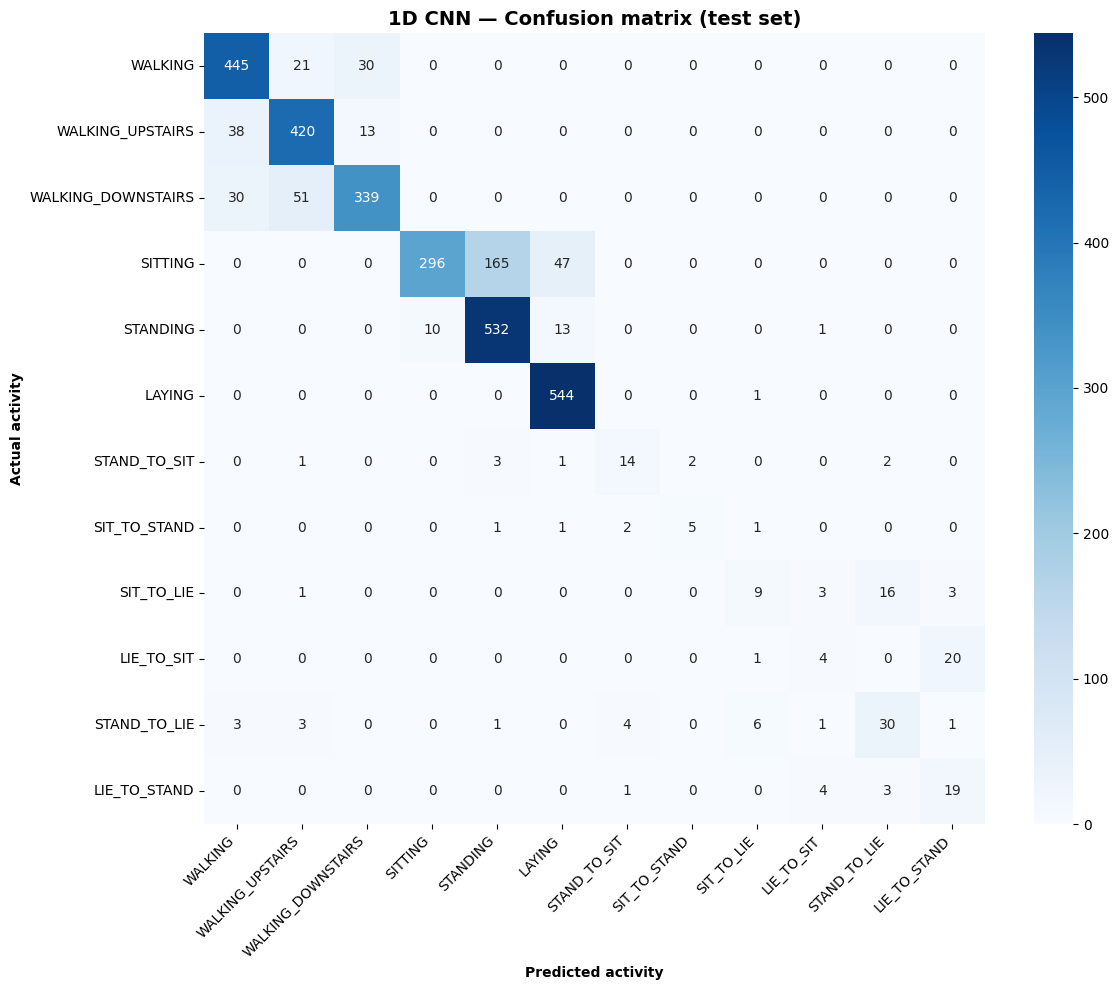

In [8]:
cm = confusion_matrix(y_test_0, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names, yticklabels=label_names
)
plt.xlabel('Predicted activity', fontweight='bold')
plt.ylabel('Actual activity',    fontweight='bold')
plt.title('1D CNN — Confusion matrix (test set)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn1d.png', dpi=150)
plt.show()

In [9]:
print(set(true_names) - set(label_names))
print(set(pred_names) - set(label_names))
print("Unique predicted classes:", np.unique(y_pred))
print("Unique true classes:", np.unique(y_test_0))

set()
set()
Unique predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Unique true classes: [ 0  1  2  3  4  5  6  7  8  9 10 11]


Overall pattern:
The diagonal is mostly dark blue, meaning the model correctly classifies most samples.
Errors are concentrated in a few specific areas, not scattered randomly.

Key confusions:
1. SITTING vs STANDING vs LAYING:
   - 165 SITTING samples misclassified as STANDING, and 47 as LAYING
   - biggest failure in the matrix
   - all three are quasi-static postures with low dynamic acceleration, differing mainly in body orientation relative to gravity

2. Walking activities confused with each other:
   - 38 WALKING_UPSTAIRS misclassified as WALKING
   - 30 WALKING_DOWNSTAIRS misclassified as WALKING, 51 as WALKING_UPSTAIRS
   - all three share similar rhythmic leg movement patterns, just with different gravitational components

3. Transition classes:
   - STAND_TO_SIT (14 correct out of ~23 samples) which is reasonable given tiny class size
   - SIT_TO_LIE scattered across SIT_TO_LIE, LIE_TO_SIT, STAND_TO_LIE. the model 
     confuses transitions that involve similar body movements
   - LIE_TO_SIT only 4 correct, mostly confused with LIE_TO_STAND (20).
     both start from lying down, hard to distinguish

Key insight:
Confusions happen between physically similar activities.
The model has learned meaningful structure but it struggles at the boundaries between
similar motion patterns, especially for underrepresented classes.

## 10. MIoU Score

In [10]:
miou = jaccard_score(y_test_0, y_pred, average='macro')
print(f'mIoU: {miou:.4f}')

mIoU: 0.5421


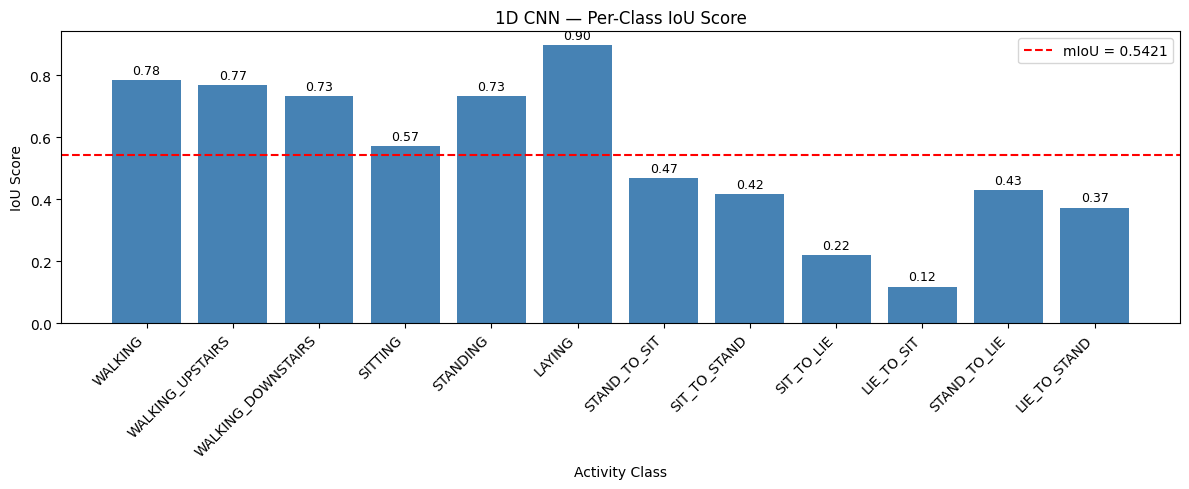

In [11]:
iou_per_class = jaccard_score(y_test_0, y_pred, average=None)

plt.figure(figsize=(12, 5))
bars = plt.bar(label_names, iou_per_class, color='steelblue')
for bar, val in zip(bars, iou_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.axhline(y=np.mean(iou_per_class), color='red', linestyle='--', 
            label=f'mIoU = {np.mean(iou_per_class):.4f}')

plt.xlabel('Activity Class')
plt.ylabel('IoU Score')
plt.title('1D CNN — Per-Class IoU Score')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('miou_cnn1d.png', dpi=150)
plt.show()

Classes above the mIoU line (0.54):
- LAYING: 0.90 — highest IoU, very distinct posture
- WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, STANDING: 0.73–0.78 — 
  all dynamic activities with strong motion signatures

Classes below the mIoU line:
- STAND_TO_SIT: 0.47, SIT_TO_STAND: 0.42, STAND_TO_LIE: 0.43, LIE_TO_STAND: 0.37
  — transition classes with low sample counts struggle
- SIT_TO_LIE: 0.22, LIE_TO_SIT: 0.12 — worst performing, barely any test samples
  (23 and 25 respectively), model has almost no data to learn from

The large spread between best (0.90) and worst (0.12) confirms that class 
imbalance is the dominant challenge

## ROC - AUC Curve

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


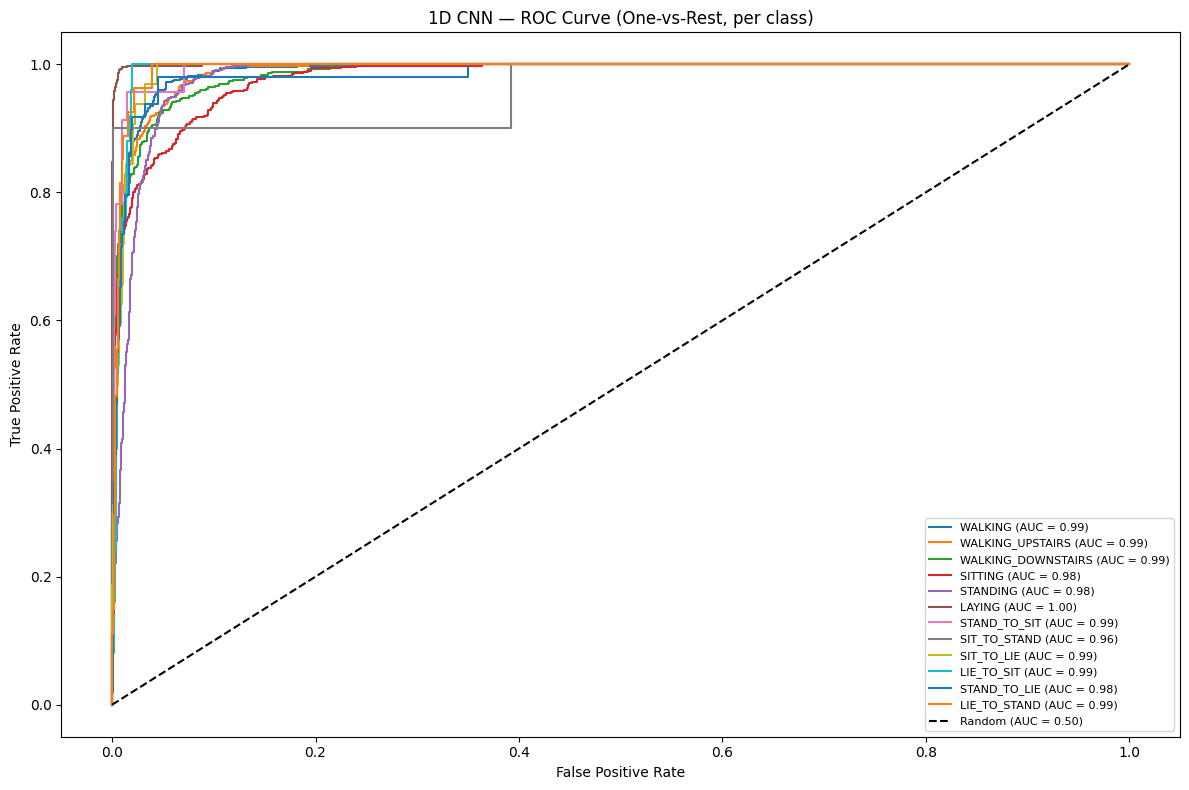

ROC AUC: 0.9871


In [12]:
y_pred_proba = model.predict(X_test_k)

y_test_onehot = to_categorical(y_test_0, num_classes=n_classes)


plt.figure(figsize=(12, 8))

for i, class_name in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('1D CNN — ROC Curve (One-vs-Rest, per class)')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curve_cnn1d.png', dpi=150)
plt.show()

roc_auc = roc_auc_score(y_test_onehot, y_pred_proba, average='macro', multi_class='ovr')
print(f'ROC AUC: {roc_auc:.4f}')

ROC AUC = 0.9871 (ROC Curve):

All 12 classes hug tightly to the top-left corner
- LAYING: AUC = 1.00 —> perfect separability
- WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, STAND_TO_SIT, 
  SIT_TO_LIE, LIE_TO_SIT, LIE_TO_STAND: AUC = 0.99 
- SIT_TO_STAND: AUC = 0.96

high AUC scores (all above 0.96) contrast with the macro F1 score (much lower at 0.67). This suggests that the model is actually quite good at distinguishing between classes overall, but it struggles when it has to make final classification decisions.